# 07 — Strategy analysis

`06_strategy` returned a verdict: 0 of 135 development cells clear costs, and
the frozen spec loses money on evaluation. This notebook asks *why*, because
the two possible explanations have completely different consequences for the
dissertation:

> **A. There is no signal.** Forward returns do not separate by sentiment at
> any horizon. Then the null is about sentiment, and it is the finding.
>
> **B. There is a signal we failed to monetise.** Returns do separate, but
> turnover, breadth or cost eat it. Then the null is about *implementation*,
> and the honest claim is much narrower.

The main diagnostic is **cumulative abnormal return in event time by signal
quantile** (§1), interpreted through its date-block intervals and declared
multiplicity family. Everything after that characterises the trading result.

All analysis is on the **development** block except §5, which re-reads the
valid corrected evaluation run already produced by `06_strategy` — no new
selection. The earlier void read remains disclosed in `INVALIDATED_RUNS.md`.

All returns use the corrected `attach_open_returns` (next *session*, not next
news day). Any figure here that disagrees with a pre-2026-07-31 run is right.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import AGGREGATOR_NAMES, benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import DEFAULT_SIGNAL_ORIENT  # noqa: E402
from final_experiments.lib.panel import DEFAULT_PRICE_ZIP, load_adjusted_open_prices  # noqa: E402
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    ORDINAL_BLUE,
    STATUS,
    apply_house_style,
    display_label,
    diverging_cmap,
    label_line_end,
    label_line_ends,
    zero_line,
)
from final_experiments.lib.strategy import (  # noqa: E402
    DEFAULT_BREADTHS,
    StrategyConfig,
    build_daily_ar_panel,
    event_time_car,
    event_time_spread_inference,
    monthly_return_matrix,
    rolling_annualized_sharpe,
    run_backtest,
)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


apply_house_style()

OUT = REPO_ROOT / "final_experiments" / "outputs" / "07_strategy_analysis"
OUT.mkdir(parents=True, exist_ok=True)
SRC = REPO_ROOT / "final_experiments" / "outputs" / "06_strategy"
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"

COST_BPS = 10.0
MAX_LAG = 20
N_QUANTILES = 5

agg = pd.read_parquet(AGG_PATH)
agg["session_date"] = pd.to_datetime(agg["session_date"]).dt.normalize()
prices, _ = load_adjusted_open_prices(DEFAULT_PRICE_ZIP, set(agg["symbol"].astype(str)))
daily_ar = build_daily_ar_panel(prices, market_symbol="SPY")

sweep = pd.read_csv(SRC / "development_sweep.csv")
spec = json.loads((SRC / "frozen_spec.json").read_text())
strategy_manifest = json.loads((SRC / "manifest.json").read_text())
post_change_policy = strategy_manifest["post_change_policy"]
post_change_improvement_pp = float(strategy_manifest["post_change_improvement_percentage_points"])
dev_daily = pd.read_csv(SRC / "development_daily.csv", parse_dates=["session_date"])
eval_daily = pd.read_csv(SRC / "evaluation_daily.csv", parse_dates=["session_date"])

print(f"frozen spec: {spec['signal']}  horizon={spec['horizon']}  breadth={spec['breadth']:g}")
print(f"sweep cells: {len(sweep)}   development sessions: {len(dev_daily):,}   evaluation: {len(eval_daily):,}")
print(
    f"post-change policy: {post_change_policy['policy'].upper()}  "
    f"improvement={post_change_improvement_pp:+.2f} percentage points"
)

frozen spec: decayed_state  horizon=10  breadth=0.8
sweep cells: 135   development sessions: 2,263   evaluation: 1,004
post-change policy: CASH  improvement=+19.74 percentage points


## 1. Is there a signal at all? Event-time CAR by quantile

Every session, names with news are sorted into five equal groups by the
oriented signal and equally weighted. Lag *k* is the k-th session held. If
sentiment predicts returns, quantile 5 (highest signal) separates upward from
quantile 1 and the gap widens or persists. If the lines braid together, there
provides no visible ordering to monetise; formal claims come from the
dependence-aware Q5−Q1 inference below.

Q1 is the lowest-signal group and Q5 the highest, so the ramp is ordered
light→dark rather than five arbitrary hues — rank should be readable without
consulting a legend.

In [2]:
# The spec's own signal must be in here — §1's per-session panel reads it directly,
# and it is the one the reader will look for.
focus_signals = ["mean_continuous", "mean_hard_label", "negative_share", spec["signal"]]
focus_signals = list(dict.fromkeys(focus_signals))
while len(focus_signals) < 4:
    for candidate in ("dispersion", "median_continuous", "decayed_state"):
        if candidate not in focus_signals:
            focus_signals.append(candidate)
            break
print("event-time signals:", focus_signals)
car_frames = []
for name in focus_signals:
    car_frames.append(
        event_time_car(
            agg,
            daily_ar,
            signal=name,
            orient=float(DEFAULT_SIGNAL_ORIENT.get(name, 1.0)),
            n_quantiles=N_QUANTILES,
            max_lag=MAX_LAG,
            split="development",
        )
    )
car = pd.concat(car_frames, ignore_index=True)
car.to_csv(OUT / "event_time_car.csv", index=False)
display(
    car.loc[car["lag"].isin([1, 5, 10, 20])]
    .pivot_table(index=["signal", "quantile"], columns="lag", values="cum_ar")
    .round(5)
)

event-time signals: ['mean_continuous', 'mean_hard_label', 'negative_share', 'decayed_state']


lag                            1        5        10       20
signal          quantile                                    
decayed_state   1        -0.00016 -0.00026 -0.00026 -0.00082
                2        -0.00003 -0.00037 -0.00075 -0.00204
                3         0.00008 -0.00059 -0.00092 -0.00134
                4        -0.00014 -0.00070 -0.00137 -0.00242
                5         0.00002 -0.00014 -0.00072 -0.00129
mean_continuous 1        -0.00016 -0.00045 -0.00046 -0.00108
                2        -0.00000 -0.00046 -0.00087 -0.00181
                3        -0.00003 -0.00046 -0.00089 -0.00185
                4        -0.00000 -0.00035 -0.00104 -0.00164
                5        -0.00004 -0.00034 -0.00078 -0.00154
mean_hard_label 1        -0.00015 -0.00033 -0.00044 -0.00105
                2        -0.00004 -0.00043 -0.00070 -0.00119
                3         0.00000 -0.00061 -0.00116 -0.00227
                4        -0.00001 -0.00036 -0.00090 -0.00197
                5        -0.00003 -0.00033 -0.00084 -0.00145
negative_share  1        -0.00016 -0.00045 -0.00055 -0.00104
                2         0.00001 -0.00016 -0.00033 -0.00122
                3        -0.00008 -0.00066 -0.00124 -0.00172
                4         0.00001 -0.00047 -0.00106 -0.00202
                5        -0.00000 -0.00032 -0.00087 -0.00193

findfont: Failed to find font weight medium, now using 400.


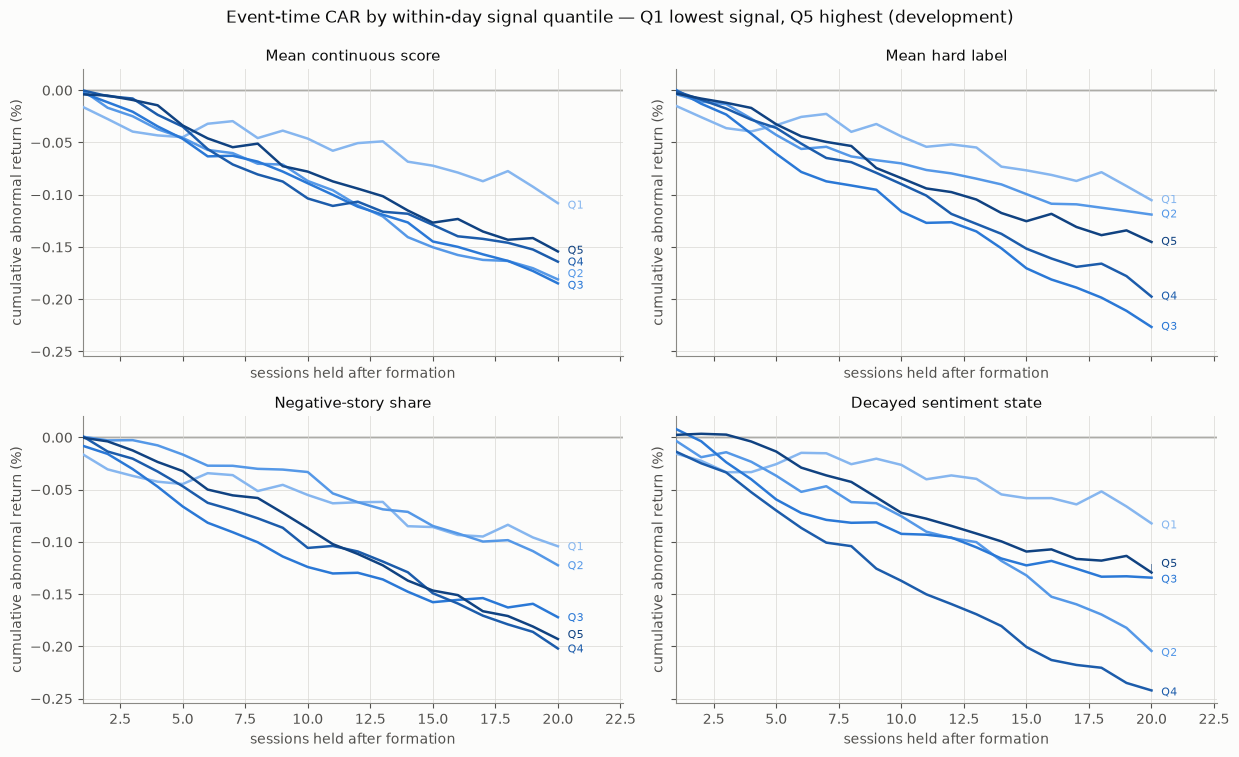

Every quantile drifts DOWN together. That common component is a property of
news-bearing firm-days on a selected panel, not a signal — and a dollar-neutral
long/short book cancels it exactly. The next figure removes it.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), focus_signals, strict=True):
    sub = car.loc[car["signal"] == name]
    ends = []
    for q in range(1, N_QUANTILES + 1):
        line = sub.loc[sub["quantile"] == q].sort_values("lag")
        colour = ORDINAL_BLUE[q - 1]
        ax.plot(line["lag"], 100 * line["cum_ar"], color=colour, lw=1.8, zorder=3)
        ends.append((float(line["lag"].iloc[-1]), 100 * float(line["cum_ar"].iloc[-1]), f"Q{q}", colour))
    zero_line(ax)
    ax.set_title(display_label(name))
    ax.set_xlabel("sessions held after formation")
    ax.set_ylabel("cumulative abnormal return (%)")
    ax.set_xlim(1, MAX_LAG + 2.6)
    label_line_ends(ax, ends)
fig.suptitle(
    "Event-time CAR by within-day signal quantile — Q1 lowest signal, Q5 highest (development)",
    y=0.99,
)
fig.tight_layout()
fig.savefig(OUT / "event_time_car_by_quantile.png", dpi=150)
plt.show()

print(
    "Every quantile drifts DOWN together. That common component is a property of\n"
    "news-bearing firm-days on a selected panel, not a signal — and a dollar-neutral\n"
    "long/short book cancels it exactly. The next figure removes it."
)

### The same lines with the common drift removed

The strategy is dollar-neutral, so it cannot earn (or lose) the component
shared by every quantile. Subtracting the cross-quantile mean at each lag
leaves precisely the part a long/short book can capture — and rescales the
axis from "all news drifts down" to the spread that is actually in dispute.

Note the y-axis units: **basis points**, where the previous figure was in
percent. If the signal worked, Q5 would sit at the top and Q1 at the bottom.

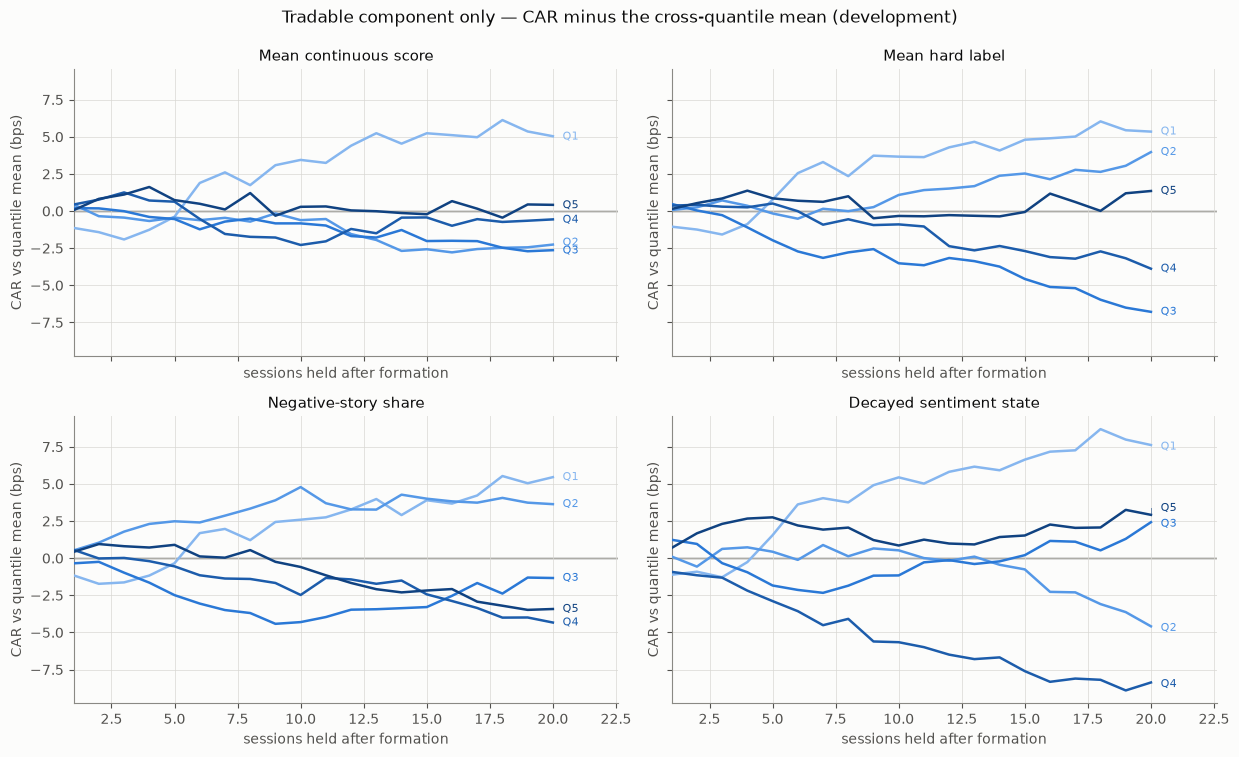

,lag_1,lag_5,lag_20
signal,,,
decayed_state,0.5,0.0,-0.3
mean_continuous,0.1,0.6,-0.1
mean_hard_label,0.6,0.3,-0.6
negative_share,0.5,-0.1,-0.9


Spearman(quantile, demeaned CAR). +1 means the quantiles are perfectly ordered
low→high, which is what a working signal looks like.

Descriptively, the ordering changes from lag 1 (mean +0.42) to lag 20 (-0.47). This pattern is not evidence of reversal until the Q5−Q1 path survives dependence-aware inference and multiplicity correction below.


In [4]:
car["cum_ar_demeaned"] = car["cum_ar"] - car.groupby(["signal", "lag"])["cum_ar"].transform("mean")
car.to_csv(OUT / "event_time_car.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), focus_signals, strict=True):
    sub = car.loc[car["signal"] == name]
    ends = []
    for q in range(1, N_QUANTILES + 1):
        line = sub.loc[sub["quantile"] == q].sort_values("lag")
        colour = ORDINAL_BLUE[q - 1]
        ax.plot(line["lag"], 1e4 * line["cum_ar_demeaned"], color=colour, lw=1.8, zorder=3)
        ends.append(
            (float(line["lag"].iloc[-1]), 1e4 * float(line["cum_ar_demeaned"].iloc[-1]), f"Q{q}", colour)
        )
    zero_line(ax)
    ax.set_title(display_label(name))
    ax.set_xlabel("sessions held after formation")
    ax.set_ylabel("CAR vs quantile mean (bps)")
    ax.set_xlim(1, MAX_LAG + 2.6)
    label_line_ends(ax, ends)
fig.suptitle(
    "Tradable component only — CAR minus the cross-quantile mean (development)", y=0.99
)
fig.tight_layout()
fig.savefig(OUT / "event_time_car_demeaned.png", dpi=150)
plt.show()

def _quantile_rank_corr(frame: pd.DataFrame, lag: int) -> pd.Series:
    """Spearman(quantile, demeaned CAR) per signal. +1 = perfectly ordered."""
    wide = frame.loc[frame["lag"] == lag].pivot(
        index="signal", columns="quantile", values="cum_ar_demeaned"
    )
    ladder = pd.Series(range(1, N_QUANTILES + 1))
    return wide.apply(lambda r: pd.Series(r.to_numpy()).corr(ladder, method="spearman"), axis=1)

ordering = _quantile_rank_corr(car, 1).rename("lag_1").to_frame()
ordering["lag_5"] = _quantile_rank_corr(car, 5)
ordering[f"lag_{MAX_LAG}"] = _quantile_rank_corr(car, MAX_LAG)
ordering.to_csv(OUT / "quantile_rank_correlation_by_lag.csv")
display(ordering.round(2))

print(
    "Spearman(quantile, demeaned CAR). +1 means the quantiles are perfectly ordered\n"
    "low→high, which is what a working signal looks like.\n"
)
print(
    f"Descriptively, the ordering changes from lag 1 (mean {ordering['lag_1'].mean():+.2f}) "
    f"to lag {MAX_LAG} ({ordering[f'lag_{MAX_LAG}'].mean():+.2f}). This pattern is not "
    "evidence of reversal until the Q5−Q1 path survives dependence-aware inference "
    "and multiplicity correction below."
)

### The spread that matters: Q5 − Q1

One line per signal is the long/short leg the strategy actually tries to earn.
A flat line here is the whole story.

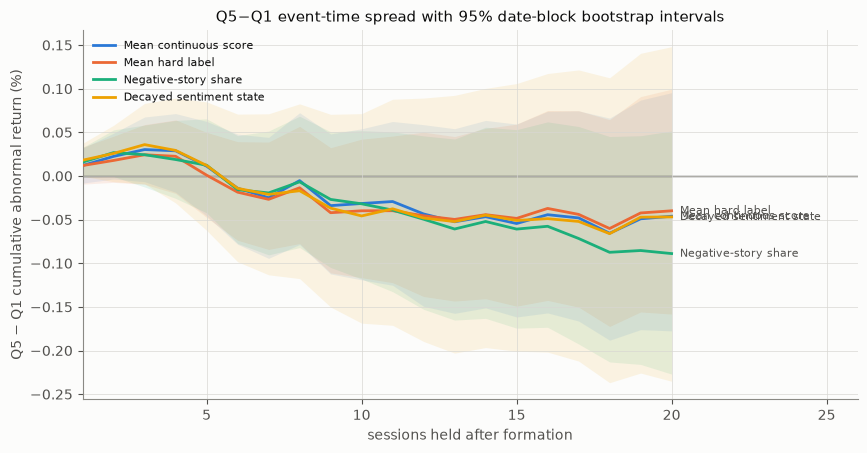

,max,min,last
signal,,,
decayed_state,0.00036,-0.00066,-0.00047
mean_continuous,0.00030,-0.00066,-0.00046
mean_hard_label,0.00024,-0.00060,-0.00040
negative_share,0.00027,-0.00089,-0.00089


,signal,lag,spread_mean_ar,spread_cum_ar,ci_low,ci_high,p_centered_block,n_formation_dates,block_length,replications,seed,bh_reject_q05,multiplicity_family


Read: the widest Q5−Q1 spread reached over 20 sessions, in percent:
  decayed_state     +0.036%
  mean_continuous   +0.030%
  mean_hard_label   +0.024%
  negative_share    +0.027%


In [5]:
spread_rows = []
for name in focus_signals:
    sub = car.loc[car["signal"] == name]
    top = sub.loc[sub["quantile"] == N_QUANTILES].set_index("lag")["cum_ar"]
    bottom = sub.loc[sub["quantile"] == 1].set_index("lag")["cum_ar"]
    for lag in top.index:
        spread_rows.append({"signal": name, "lag": int(lag), "spread": float(top[lag] - bottom[lag])})
spread = pd.DataFrame(spread_rows)
spread.to_csv(OUT / "quantile_spread.csv", index=False)

inference = pd.concat(
    [
        event_time_spread_inference(
            agg,
            daily_ar,
            signal=name,
            orient=float(DEFAULT_SIGNAL_ORIENT.get(name, 1.0)),
            n_quantiles=N_QUANTILES,
            max_lag=MAX_LAG,
            split="development",
            block_length=MAX_LAG,
            replications=999,
            seed=20260731,
        )
        for name in focus_signals
    ],
    ignore_index=True,
)
# Declared family: every displayed focus signal × every displayed event-time lag.
inference["bh_reject_q05"] = benjamini_hochberg(
    inference["p_centered_block"].fillna(1.0).tolist(), q=0.05
)
inference["multiplicity_family"] = (
    f"{len(focus_signals)} displayed signals x {MAX_LAG} event-time lags"
)
inference.to_csv(OUT / "event_time_spread_inference.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
for i, name in enumerate(focus_signals):
    sub = inference.loc[inference["signal"] == name].sort_values("lag")
    x = sub["lag"].to_numpy(dtype=float)
    y = 100 * sub["spread_cum_ar"].to_numpy(dtype=float)
    ax.plot(x, y, color=CATEGORICAL[i], lw=2.0, label=display_label(name), zorder=3)
    ax.fill_between(
        x,
        100 * sub["ci_low"].to_numpy(dtype=float),
        100 * sub["ci_high"].to_numpy(dtype=float),
        color=CATEGORICAL[i],
        alpha=0.10,
        lw=0,
    )
    label_line_end(ax, float(x[-1]), float(y[-1]), display_label(name), CATEGORICAL[i])
zero_line(ax)
ax.set_xlabel("sessions held after formation")
ax.set_ylabel("Q5 − Q1 cumulative abnormal return (%)")
ax.set_xlim(1, MAX_LAG + 6)
ax.set_title("Q5−Q1 event-time spread with 95% date-block bootstrap intervals")
ax.legend(loc="upper left", fontsize=8)
fig.savefig(OUT / "quantile_spread.png", dpi=150)
plt.show()

peak = spread.groupby("signal")["spread"].agg(["max", "min", "last"]).round(5)
display(peak)
display(inference.loc[inference["bh_reject_q05"]].round(6))
print(
    "Read: the widest Q5−Q1 spread reached over 20 sessions, in percent:\n"
    + "\n".join(f"  {s:<18}{100 * v:+.3f}%" for s, v in peak["max"].items())
)

### Where in event time does the return arrive?

Per-session mean AR for the top and bottom quantile. These error bars are
descriptive standard errors; formal inference is the block-bootstrap Q5−Q1
family above.

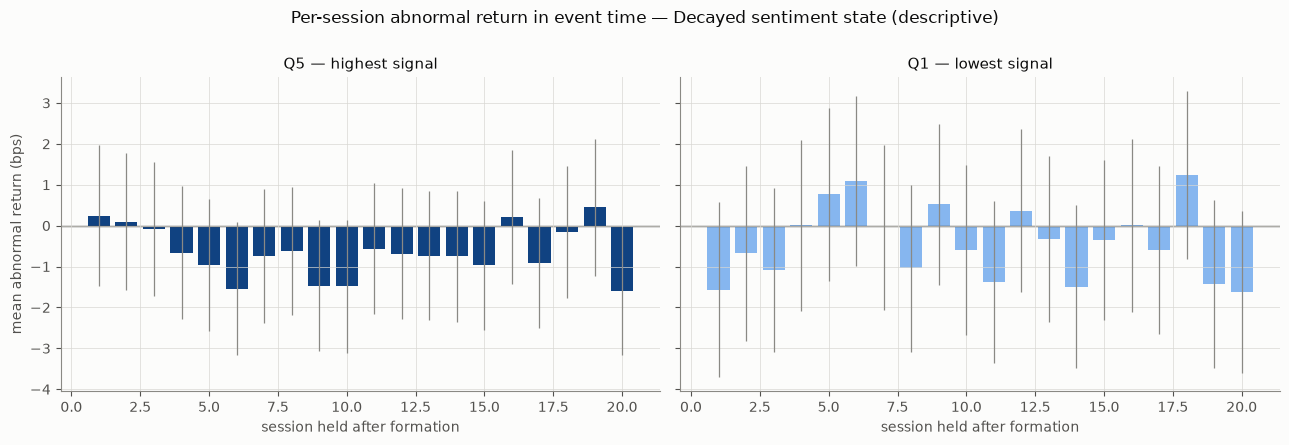

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, q, title in (
    (axes[0], N_QUANTILES, f"Q{N_QUANTILES} — highest signal"),
    (axes[1], 1, "Q1 — lowest signal"),
):
    sub = car.loc[(car["signal"] == spec["signal"]) & (car["quantile"] == q)].sort_values("lag")
    ax.bar(
        sub["lag"], 1e4 * sub["mean_ar"],
        yerr=1.96 * 1e4 * sub["se_ar"],
        color=ORDINAL_BLUE[q - 1], error_kw={"lw": 0.9, "ecolor": INK["muted"]},
    )
    zero_line(ax)
    ax.set_title(title)
    ax.set_xlabel("session held after formation")
axes[0].set_ylabel("mean abnormal return (bps)")
fig.suptitle(f"Per-session abnormal return in event time — {display_label(spec['signal'])} (descriptive)", y=1.0)
fig.tight_layout()
fig.savefig(OUT / "per_session_ar.png", dpi=150)
plt.show()

## 2. Is the signal monotone across quantiles?

A tradable signal should order the quantiles, not just separate the extremes.
Lag-1 mean AR per quantile, all nine rules.

findfont: Failed to find font weight medium, now using 400.


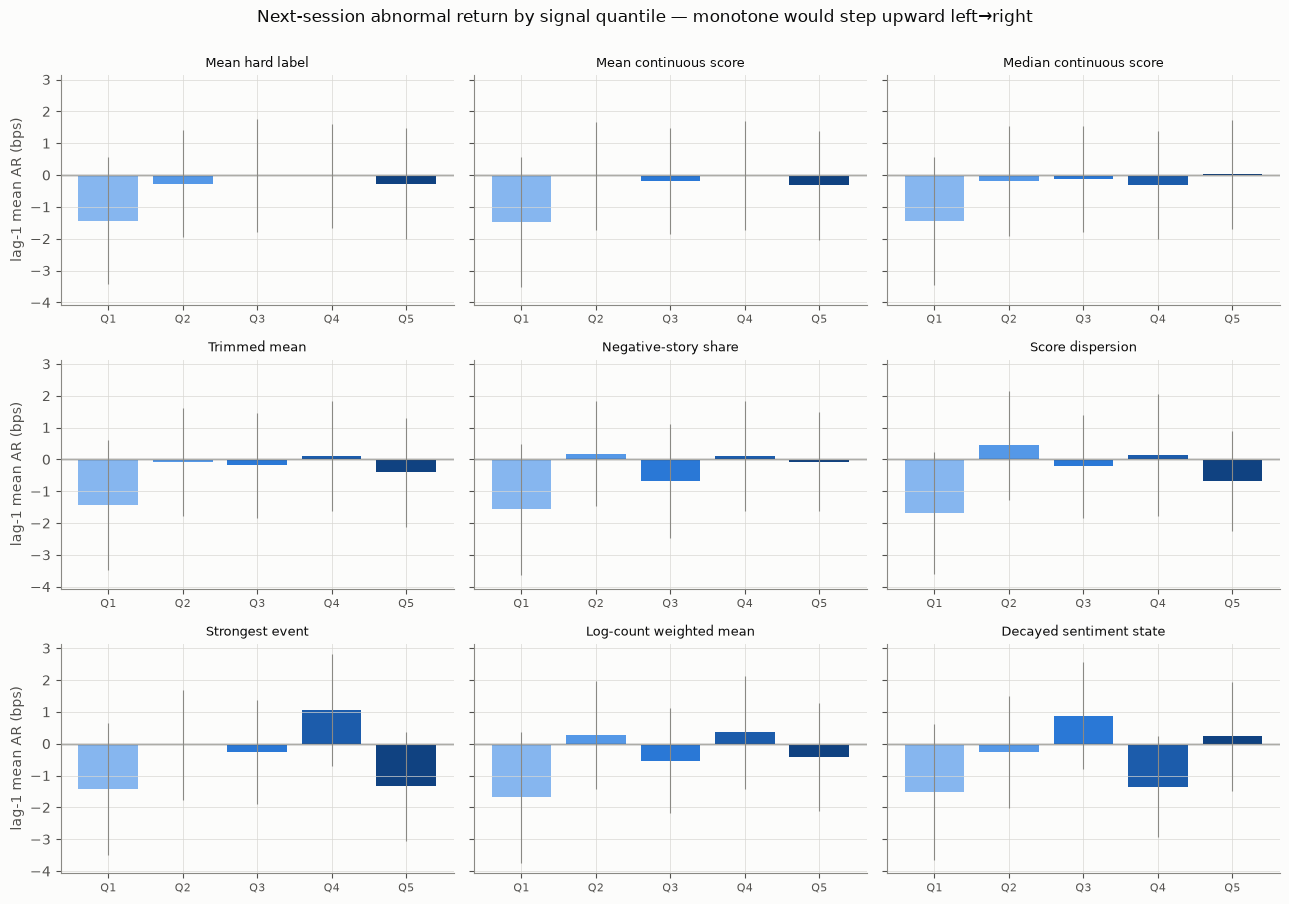

In [7]:
mono_rows = []
for name in AGGREGATOR_NAMES:
    if name not in agg.columns:
        continue
    frame = event_time_car(
        agg, daily_ar, signal=name, orient=float(DEFAULT_SIGNAL_ORIENT.get(name, 1.0)),
        n_quantiles=N_QUANTILES, max_lag=1, split="development",
    )
    for _, row in frame.iterrows():
        mono_rows.append(
            {"signal": name, "quantile": int(row["quantile"]),
             "mean_ar_bps": 1e4 * float(row["mean_ar"]), "se_bps": 1e4 * float(row["se_ar"])}
        )
mono = pd.DataFrame(mono_rows)
mono.to_csv(OUT / "quantile_monotonicity.csv", index=False)

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharey=True)
for ax, name in zip(axes.ravel(), AGGREGATOR_NAMES, strict=True):
    sub = mono.loc[mono["signal"] == name].sort_values("quantile")
    ax.bar(
        sub["quantile"], sub["mean_ar_bps"], yerr=1.96 * sub["se_bps"],
        color=[ORDINAL_BLUE[q - 1] for q in sub["quantile"]],
        error_kw={"lw": 0.8, "ecolor": INK["muted"]},
    )
    zero_line(ax)
    ax.set_title(display_label(name), fontsize=9.5)
    ax.set_xticks(range(1, N_QUANTILES + 1))
    ax.set_xticklabels([f"Q{q}" for q in range(1, N_QUANTILES + 1)], fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("lag-1 mean AR (bps)")
fig.suptitle("Next-session abnormal return by signal quantile — monotone would step upward left→right", y=1.0)
fig.tight_layout()
fig.savefig(OUT / "quantile_monotonicity.png", dpi=150)
plt.show()

## 3. The sweep surface

Development net Sharpe over horizon × breadth. Signed quantity, so the scale
diverges from a **neutral grey** at zero — a coloured midpoint would make "no
effect" look like a result.

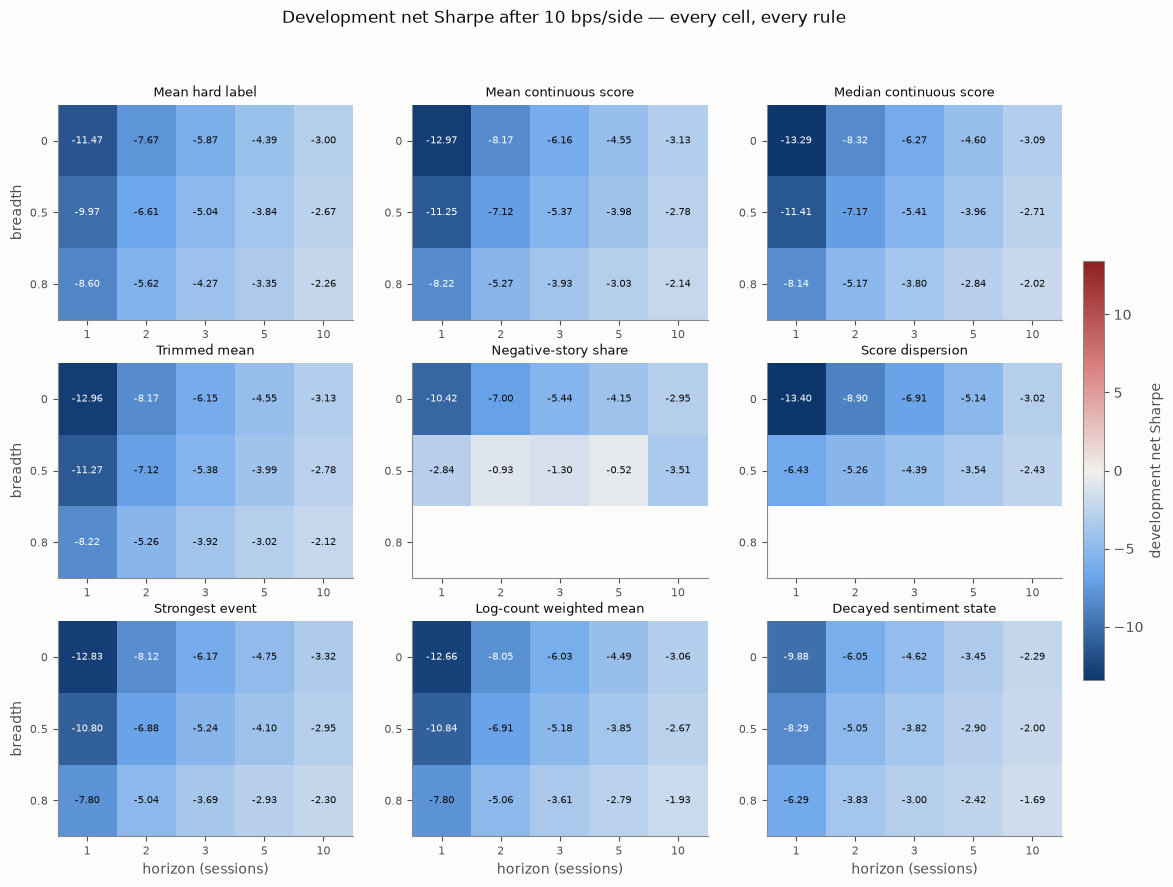

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 9.5))
limit = float(np.nanmax(np.abs(sweep["sharpe_net"])))
cmap = diverging_cmap()
for ax, name in zip(axes.ravel(), AGGREGATOR_NAMES, strict=True):
    pivot = (
        sweep.loc[sweep["signal"] == name]
        .pivot(index="breadth", columns="horizon", values="sharpe_net")
        .sort_index()
    )
    im = ax.imshow(pivot.to_numpy(), cmap=cmap, vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{b:g}" for b in pivot.index], fontsize=8)
    ax.set_title(display_label(name), fontsize=9.5)
    ax.grid(False)
    values = pivot.to_numpy()
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(
                j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                color=INK["primary"] if abs(values[i, j]) < 0.6 * limit else INK["surface"],
            )
for ax in axes[-1, :]:
    ax.set_xlabel("horizon (sessions)")
for ax in axes[:, 0]:
    ax.set_ylabel("breadth")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="development net Sharpe")
fig.suptitle("Development net Sharpe after 10 bps/side — every cell, every rule", y=0.98)
fig.savefig(OUT / "sweep_surface_net_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()

### Do the two levers do what they were supposed to?

Longer holds *should* cut turnover mechanically; concentrating breadth *should*
raise the average signal strength of the book. Both can work and still not
produce a viable strategy — that is the case worth showing plainly.

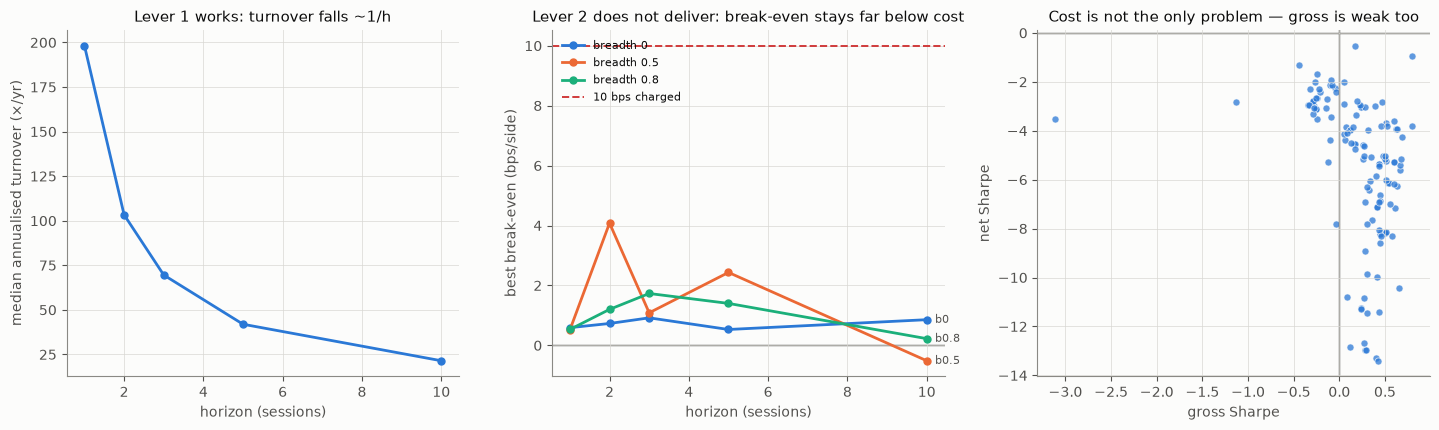

Cells with POSITIVE gross Sharpe : 94 of 135
Cells with POSITIVE net Sharpe   : 0 of 135
Cells clearing 10 bps break-even : 0 of 135


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
by_h = sweep.groupby("horizon")["annualized_turnover"].median()
axes[0].plot(by_h.index, by_h.to_numpy(), marker="o", color=CATEGORICAL[0])
axes[0].set_xlabel("horizon (sessions)")
axes[0].set_ylabel("median annualised turnover (×/yr)")
axes[0].set_title("Lever 1 works: turnover falls ~1/h")

for i, breadth in enumerate(DEFAULT_BREADTHS):
    sub = sweep.loc[sweep["breadth"] == breadth].groupby("horizon")["breakeven_bps_per_side"].max()
    axes[1].plot(sub.index, sub.to_numpy(), marker="o", color=CATEGORICAL[i], label=f"breadth {breadth:g}")
    label_line_end(axes[1], float(sub.index[-1]), float(sub.to_numpy()[-1]), f"b{breadth:g}", CATEGORICAL[i])
axes[1].axhline(COST_BPS, color=STATUS["critical"], ls="--", lw=1.4, label=f"{COST_BPS:g} bps charged")
zero_line(axes[1])
axes[1].set_xlabel("horizon (sessions)")
axes[1].set_ylabel("best break-even (bps/side)")
axes[1].set_title("Lever 2 does not deliver: break-even stays far below cost")
axes[1].legend(fontsize=8, loc="upper left")

axes[2].scatter(
    sweep["sharpe_gross"], sweep["sharpe_net"], s=26,
    color=CATEGORICAL[0], alpha=0.75, edgecolors=INK["surface"], linewidths=0.6,
)
zero_line(axes[2])
zero_line(axes[2], axis="x")
axes[2].set_xlabel("gross Sharpe")
axes[2].set_ylabel("net Sharpe")
axes[2].set_title("Cost is not the only problem — gross is weak too")
fig.tight_layout()
fig.savefig(OUT / "levers.png", dpi=150)
plt.show()

print(f"Cells with POSITIVE gross Sharpe : {int((sweep['sharpe_gross'] > 0).sum())} of {len(sweep)}")
print(f"Cells with POSITIVE net Sharpe   : {int((sweep['sharpe_net'] > 0).sum())} of {len(sweep)}")
print(f"Cells clearing {COST_BPS:g} bps break-even : {int((sweep['breakeven_bps_per_side'] > COST_BPS).sum())} of {len(sweep)}")

## 4. Every rule as an equity curve

At the frozen horizon and breadth, all nine rules, gross and net. Nine series
is too many for one set of hues, so this is small multiples with a shared
scale — the comparison is between panels, not between colours.

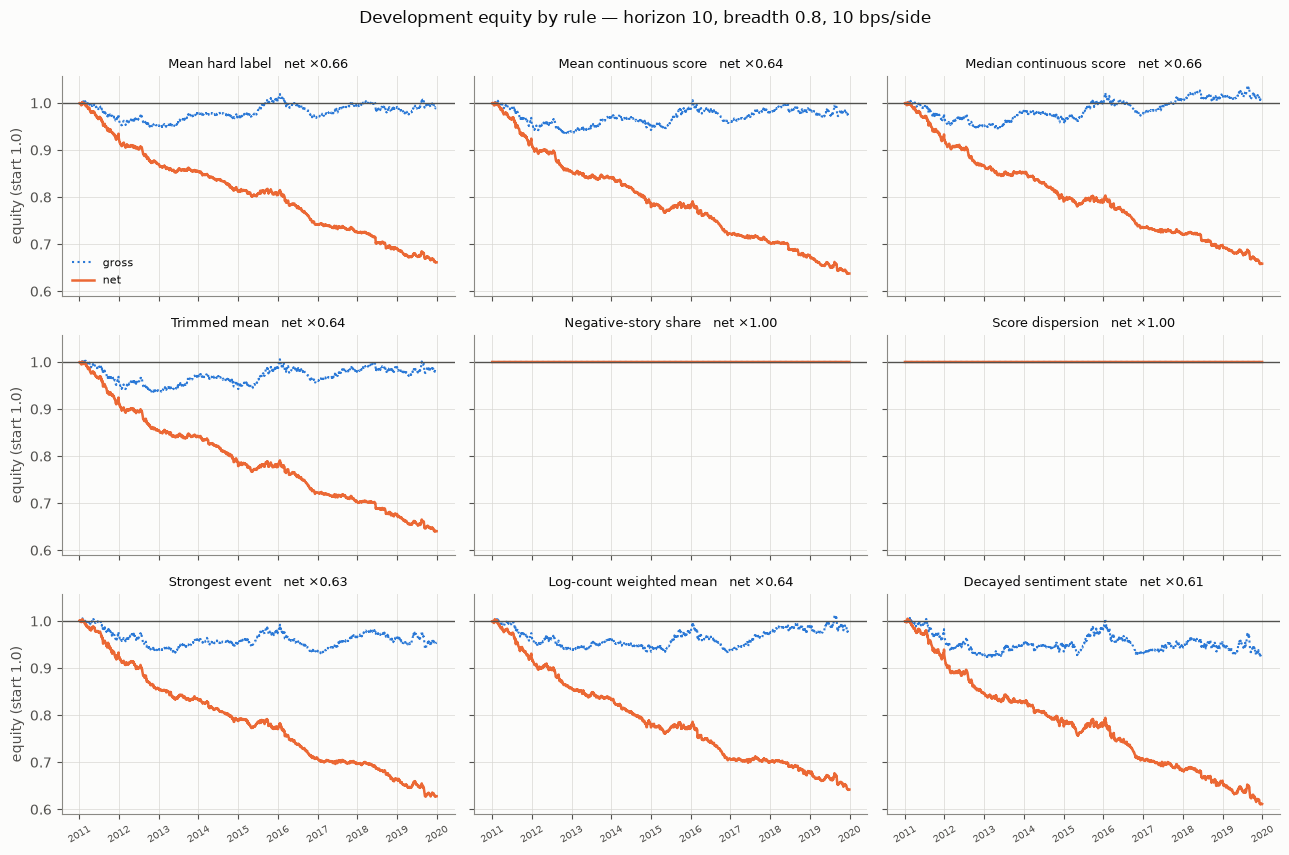

In [10]:
curves: dict[str, pd.DataFrame] = {}
for name in AGGREGATOR_NAMES:
    if name not in agg.columns:
        continue
    result = run_backtest(
        agg, daily_ar,
        StrategyConfig(
            signal=name, horizon=int(spec["horizon"]), breadth=float(spec["breadth"]),
            orient=float(DEFAULT_SIGNAL_ORIENT.get(name, 1.0)),
            cost_bps_per_side=COST_BPS, min_names=int(spec["min_names"]),
        ),
        split="development",
    )
    if not result.daily.empty:
        curves[name] = result.daily

fig, axes = plt.subplots(3, 3, figsize=(13, 8.5), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), AGGREGATOR_NAMES, strict=True):
    daily = curves.get(name)
    if daily is None:
        ax.set_visible(False)
        continue
    gross_eq = np.cumprod(1.0 + daily["gross_return"].to_numpy(dtype=float))
    net_eq = np.cumprod(1.0 + daily["net_return"].to_numpy(dtype=float))
    ax.plot(daily["session_date"], gross_eq, color=CATEGORICAL[0], lw=1.5, ls=":", label="gross")
    ax.plot(daily["session_date"], net_eq, color=CATEGORICAL[1], lw=1.8, label="net")
    ax.axhline(1.0, color=INK["reference"], lw=1.0)
    ax.set_title(f"{display_label(name)}   net ×{net_eq[-1]:.2f}", fontsize=9.5)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7.5)
axes[0, 0].legend(fontsize=8, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel("equity (start 1.0)")
fig.suptitle(
    f"Development equity by rule — horizon {spec['horizon']}, breadth {spec['breadth']:g}, {COST_BPS:g} bps/side",
    y=1.0,
)
fig.tight_layout()
fig.savefig(OUT / "equity_by_rule.png", dpi=150)
plt.show()

## 5. Historical traded spec and recomputed policy

The historical traded arm remains visible for provenance. The explicitly
authorised post-change policy from `06_strategy` is overlaid on the same
evaluation dates. This is an iterative/retrospective comparison, not a claim
that the evaluation block remained untouched.

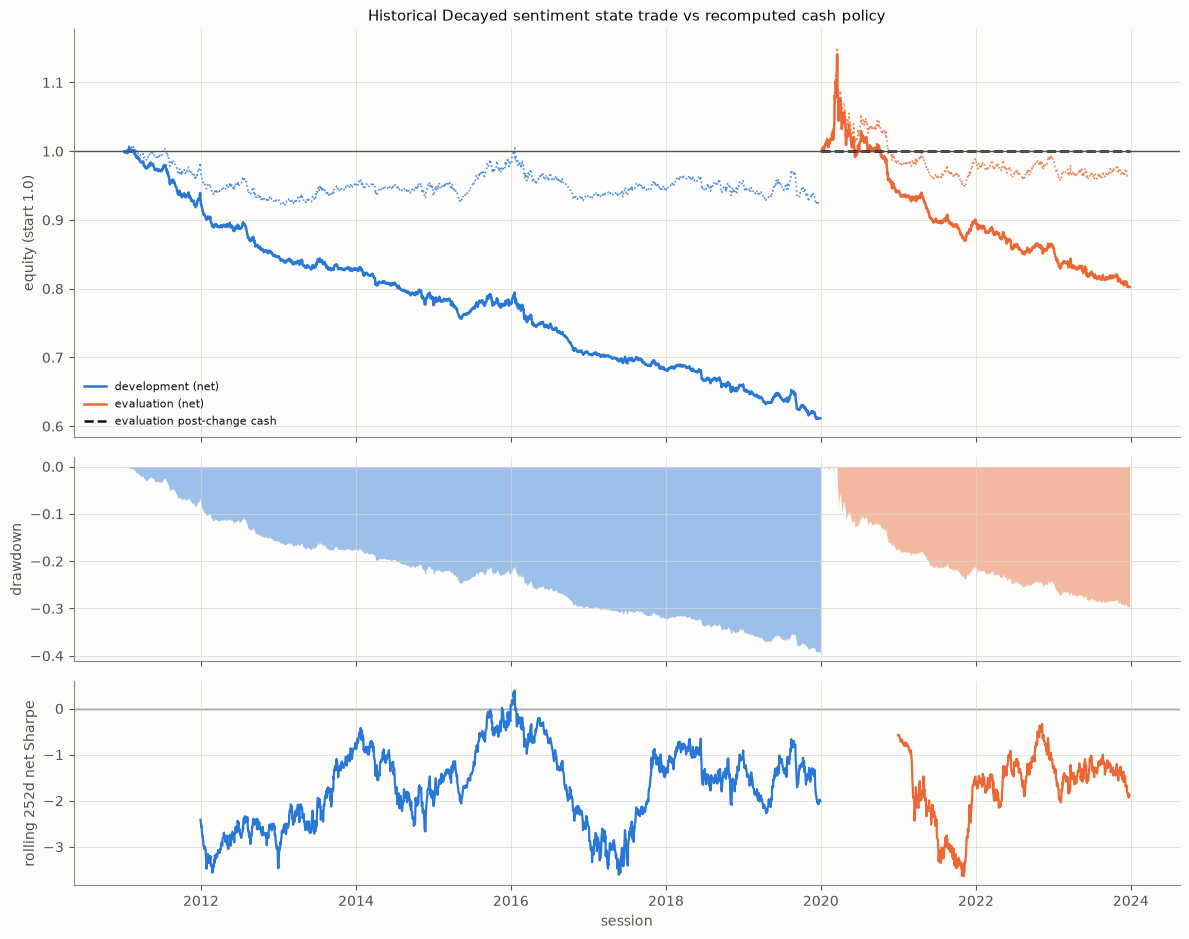

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9.5), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
for label, daily, colour in (
    ("development", dev_daily, CATEGORICAL[0]),
    ("evaluation", eval_daily, CATEGORICAL[1]),
):
    net_eq = np.cumprod(1.0 + daily["net_return"].to_numpy(dtype=float))
    gross_eq = np.cumprod(1.0 + daily["gross_return"].to_numpy(dtype=float))
    axes[0].plot(daily["session_date"], gross_eq, color=colour, lw=1.2, ls=":", alpha=0.8)
    axes[0].plot(daily["session_date"], net_eq, color=colour, lw=1.8, label=f"{label} (net)")
    axes[1].fill_between(
        daily["session_date"], net_eq / np.maximum.accumulate(net_eq) - 1.0, 0.0,
        color=colour, alpha=0.45, lw=0,
    )
    roll = rolling_annualized_sharpe(daily, window=252)
    axes[2].plot(daily["session_date"], roll.to_numpy(), color=colour, lw=1.6)

if post_change_policy["policy"] == "cash":
    axes[0].plot(
        eval_daily["session_date"],
        np.ones(len(eval_daily)),
        color=INK["primary"],
        lw=1.8,
        ls="--",
        label="evaluation post-change cash",
    )
axes[0].axhline(1.0, color=INK["reference"], lw=1.0)
axes[0].set_ylabel("equity (start 1.0)")
axes[0].set_title(
    f"Historical {display_label(spec['signal'])} trade vs recomputed {post_change_policy['policy']} policy"
)
axes[0].legend(fontsize=8, loc="lower left")
axes[1].set_ylabel("drawdown")
zero_line(axes[2])
axes[2].set_ylabel("rolling 252d net Sharpe")
axes[2].set_xlabel("session")
fig.tight_layout()
fig.savefig(OUT / "frozen_spec_detail.png", dpi=150)
plt.show()

### Monthly calendar

Historical traded-arm returns on a diverging scale with a neutral midpoint.
This reveals whether the avoided losses were chronic or a few bad months; the
recomputed cash policy is flat by construction.

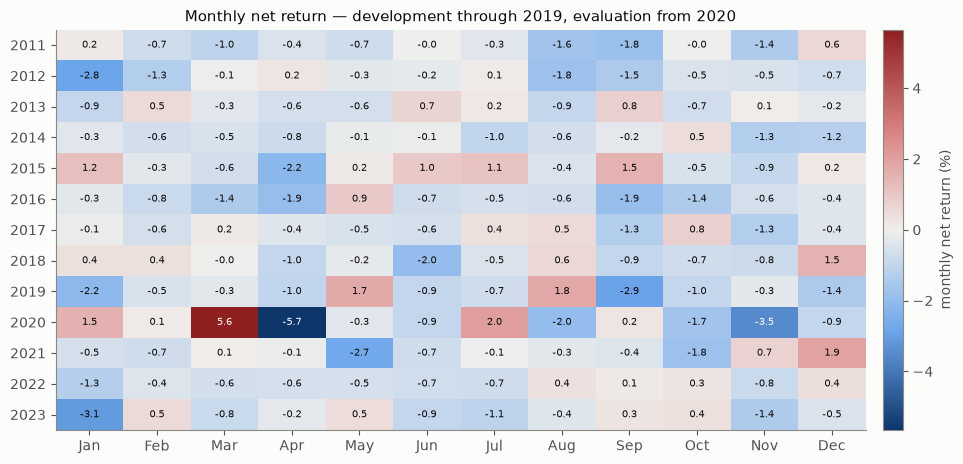

In [12]:
monthly = pd.concat(
    [monthly_return_matrix(dev_daily), monthly_return_matrix(eval_daily)]
).groupby(level=0).first()
monthly.to_csv(OUT / "monthly_returns.csv")

fig, ax = plt.subplots(figsize=(11, 5.2))
values = 100 * monthly.to_numpy(dtype=float)
limit = float(np.nanmax(np.abs(values)))
im = ax.imshow(values, cmap=diverging_cmap(), vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(monthly.shape[1]))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][: monthly.shape[1]]
)
ax.set_yticks(range(monthly.shape[0]))
ax.set_yticklabels(monthly.index)
ax.grid(False)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        if np.isfinite(values[i, j]):
            ax.text(
                j, i, f"{values[i, j]:.1f}", ha="center", va="center", fontsize=7.5,
                color=INK["primary"] if abs(values[i, j]) < 0.6 * limit else INK["surface"],
            )
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="monthly net return (%)")
ax.set_title("Monthly net return — development through 2019, evaluation from 2020")
fig.savefig(OUT / "monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Return distribution and book health

For the historical traded arm, is the loss a fat tail or a steady bleed, and
was the book actually the book we
think it was? `missing_weight_share` is held weight whose return was
unavailable — a delisting check.

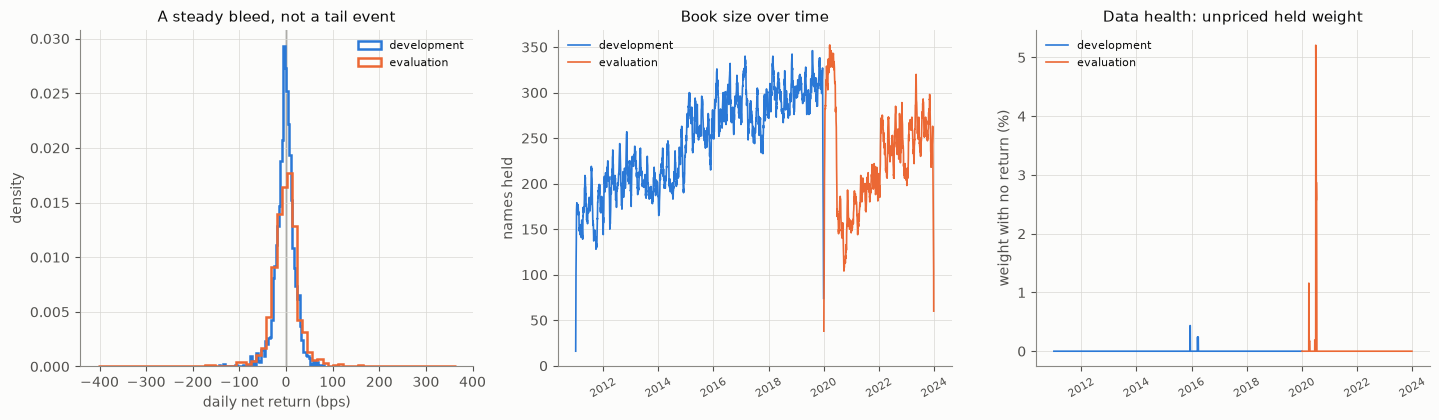

net exposure — development max |·| : 6.77e-16
net exposure — evaluation  max |·| : 3.05e-16
unpriced held weight — worst session: 5.21%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
for label, daily, colour in (
    ("development", dev_daily, CATEGORICAL[0]),
    ("evaluation", eval_daily, CATEGORICAL[1]),
):
    net = daily["net_return"].to_numpy(dtype=float)
    axes[0].hist(1e4 * net, bins=70, histtype="step", lw=1.8, color=colour, label=label, density=True)
zero_line(axes[0], axis="x")
axes[0].set_xlabel("daily net return (bps)")
axes[0].set_ylabel("density")
axes[0].set_title("A steady bleed, not a tail event")
axes[0].legend(fontsize=8)

for label, daily, colour in (
    ("development", dev_daily, CATEGORICAL[0]),
    ("evaluation", eval_daily, CATEGORICAL[1]),
):
    axes[1].plot(daily["session_date"], daily["n_positions"], color=colour, lw=1.2, label=label)
axes[1].set_ylabel("names held")
axes[1].set_title("Book size over time")
axes[1].tick_params(axis="x", labelrotation=30, labelsize=8)
axes[1].legend(fontsize=8)

for label, daily, colour in (
    ("development", dev_daily, CATEGORICAL[0]),
    ("evaluation", eval_daily, CATEGORICAL[1]),
):
    axes[2].plot(daily["session_date"], 100 * daily["missing_weight_share"], color=colour, lw=1.2, label=label)
axes[2].set_ylabel("weight with no return (%)")
axes[2].set_title("Data health: unpriced held weight")
axes[2].tick_params(axis="x", labelrotation=30, labelsize=8)
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "distribution_and_book_health.png", dpi=150)
plt.show()

print(f"net exposure — development max |·| : {dev_daily['net_exposure'].abs().max():.2e}")
print(f"net exposure — evaluation  max |·| : {eval_daily['net_exposure'].abs().max():.2e}")
worst_unpriced = 100 * max(
    dev_daily["missing_weight_share"].max(), eval_daily["missing_weight_share"].max()
)
print(f"unpriced held weight — worst session: {worst_unpriced:.2f}%")

## 6. Recomputed verdict: signal versus policy

Neither label is quite right, and the third reading is the defensible one.
Read the numbers below together rather than picking the convenient one.

In [14]:
max_spread_bps = 1e4 * float(spread["spread"].abs().max())
final_spread_bps = 1e4 * float(
    spread.loc[spread["lag"] == spread["lag"].max()].set_index("signal")["spread"].mean()
)
gross_positive = int((sweep["sharpe_gross"] > 0).sum())
mono_range = float(mono.groupby("signal")["mean_ar_bps"].agg(lambda s: s.max() - s.min()).max())
round_trip_bps = 2.0 * COST_BPS
ratio = round_trip_bps / mono_range if mono_range > 0 else float("inf")
event_survivors = int(inference["bh_reject_q05"].sum())
historical_total_return = float(strategy_manifest["evaluation"]["total_return_net"])
post_change_total_return = float(post_change_policy["total_return_net"])
survivor_text = (
    f"{event_survivors} signal-lag cells survive BH within the declared event-time family."
    if event_survivors
    else "No signal-lag cell survives BH within the declared event-time family."
)

verdict = {
    "notebook": "07_strategy_analysis",
    "question": "Is the 06_strategy null about sentiment (A) or about implementation (B)?",
    "widest_q5_minus_q1_spread_bps_over_20_sessions": max_spread_bps,
    "mean_q5_minus_q1_spread_at_max_lag_bps": final_spread_bps,
    "widest_lag1_quantile_range_bps": mono_range,
    "round_trip_cost_bps": round_trip_bps,
    "cost_to_signal_ratio": ratio,
    "cells_with_positive_gross_sharpe": gross_positive,
    "cells_with_positive_net_sharpe": int((sweep["sharpe_net"] > 0).sum()),
    "cells_total": int(len(sweep)),
    "cells_clearing_cost": int((sweep["breakeven_bps_per_side"] > COST_BPS).sum()),
    "event_time_multiplicity_family": str(inference["multiplicity_family"].iloc[0]),
    "event_time_bh_survivors": event_survivors,
    "frozen_spec": spec,
    "historical_total_return_net": historical_total_return,
    "post_change_policy": post_change_policy,
    "post_change_total_return_net": post_change_total_return,
    "post_change_improvement_percentage_points": post_change_improvement_pp,
    "lag1_quantile_rank_corr_mean": float(ordering["lag_1"].mean()),
    f"lag{MAX_LAG}_quantile_rank_corr_mean": float(ordering[f"lag_{MAX_LAG}"].mean()),
    "answer": (
        "The descriptive plots show a small lag-1 ordering and a later sign change, "
        f"but those patterns must be read with the formal result: {survivor_text} "
        f"The displayed lag-1 range is ~{mono_range:.1f} bps versus a "
        f"{round_trip_bps:.0f} bps round-trip cost. The defensible conclusion is about "
        "economic non-viability; a predictive or reversal claim is retained only for "
        "cells that survive the pre-declared block-bootstrap/BH family. The "
        f"recomputed {post_change_policy['policy']} policy improves total return from "
        f"{historical_total_return:.2%} to {post_change_total_return:.2%} by abstaining, "
        "not by extracting a stronger sentiment signal."
    ),
    "returns_convention": "corrected attach_open_returns (next session, not next news day)",
    "analysis_status": "iterative_post_change_recompute_2026-08-03",
    "supersedes": "outputs/superseded/20260731_pre_rigour_repair/07_strategy_analysis",
}
(OUT / "manifest.json").write_text(json.dumps(verdict, indent=2, default=str) + "\n")

print(f"Widest Q5−Q1 spread over 20 sessions : {max_spread_bps:+.1f} bps")
print(f"Mean Q5−Q1 spread at lag {MAX_LAG:<2d}          : {final_spread_bps:+.1f} bps  (it does not accumulate)")
print(f"Widest lag-1 spread across quantiles : {mono_range:+.1f} bps")
print(f"Round-trip cost at {COST_BPS:g} bps/side        : {round_trip_bps:.0f} bps  → cost is ~{ratio:.0f}x the signal")
print(f"Cells with positive GROSS Sharpe     : {gross_positive} of {len(sweep)}")
print(f"Cells with positive NET Sharpe       : {int((sweep['sharpe_net'] > 0).sum())} of {len(sweep)}")
print(
    f"Post-change {post_change_policy['policy']} policy      : "
    f"{historical_total_return:.2%} → {post_change_total_return:.2%} "
    f"({post_change_improvement_pp:+.2f} pp)"
)
print(survivor_text)
print()
print(verdict["answer"])

Widest Q5−Q1 spread over 20 sessions : +8.9 bps
Mean Q5−Q1 spread at lag 20          : -5.5 bps  (it does not accumulate)
Widest lag-1 spread across quantiles : +2.5 bps
Round-trip cost at 10 bps/side        : 20 bps  → cost is ~8x the signal
Cells with positive GROSS Sharpe     : 94 of 135
Cells with positive NET Sharpe       : 0 of 135
Post-change cash policy      : -19.74% → 0.00% (+19.74 pp)
No signal-lag cell survives BH within the declared event-time family.

The descriptive plots show a small lag-1 ordering and a later sign change, but those patterns must be read with the formal result: No signal-lag cell survives BH within the declared event-time family. The displayed lag-1 range is ~2.5 bps versus a 20 bps round-trip cost. The defensible conclusion is about economic non-viability; a predictive or reversal claim is retained only for cells that survive the pre-declared block-bootstrap/BH family. The recomputed cash policy improves total return from -19.74% to 0.00% by abstaining

### Carry-forward

1. §1 is the figure to promote. It answers the question a reader will actually
   ask about a null — "did you just trade it badly?" — with event-time evidence
   rather than a portfolio summary.
2. Treat the descriptive sign pattern as exploratory unless its signal-lag
   cell survives the declared block-bootstrap/BH family.
3. Quantile monotonicity (§2) compactly shows that no stable ordering is
   visible; the formal null remains the corrected interval/BH result.
4. The event-time CAR also shows every quantile drifting *down* over 20
   sessions. That is a level effect common to news-bearing firm-days, not a
   signal, and it is a reminder that the panel is a selected sample.
5. A later sign change is a hypothesis-generating pattern, not a reversal
   finding, unless the corrected inference supports it. The robust result is
   the cost comparison plus the recomputed policy result: cash materially
   improves the account outcome by avoiding an unsupported trade, without
   improving the underlying sentiment signal.